In [1]:
pip install ultralytics --upgrade


   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   -------------------- ------------------- 0.5/1.0 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 4.5 MB/s eta 0:00:00
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.3.153
    Uninstalling ultralytics-8.3.153:
      Successfully uninstalled ultralytics-8.3.153
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
%matplotlib inline


In [4]:
import torch
from ultralytics import YOLO
import yaml


DATA_YAML_PATH = 'C:/Users/avyaa/OneDrive/Desktop/Pythonfiles/.venv/Scripts/traffic_wala_dataset/data.yaml'
CUSTOM_MODEL_YAML_PATH = './custom_yolo_vehicle.yaml'  # The file we created above
PRETRAINED_WEIGHTS_PATH = 'yolov8n.pt'
NUM_BACKBONE_LAYERS_TO_FREEZE = 10 
print(f"Loading custom model from: {CUSTOM_MODEL_YAML_PATH}")
model = YOLO(CUSTOM_MODEL_YAML_PATH)


print(f"Transferring weights from: {PRETRAINED_WEIGHTS_PATH}")
model.load(PRETRAINED_WEIGHTS_PATH)

#freezing the layers
print(f"Freezing the first {NUM_BACKBONE_LAYERS_TO_FREEZE} backbone layers...")

for i, layer in enumerate(model.model.model[:NUM_BACKBONE_LAYERS_TO_FREEZE]):
    print(f"  - Freezing layer {i}: {layer.__class__.__name__}")
    for param in layer.parameters():
        param.requires_grad = False

print("\nVerifying frozen layers (first Conv layer):")
print(f"Gradient required for first layer's weight: {model.model.model[0].conv.weight.requires_grad}")



print("\nStarting training on the custom model...")
model.train(
    data=DATA_YAML_PATH,
    epochs=50,
    imgsz=640,
    batch=8, # Adjust batch size based on your GPU memory
    name='yolov8n_custom_neck_vehicle_detection' # A descriptive name for the run
)

print("\nTraining complete.")


Loading custom model from: ./custom_yolo_vehicle.yaml
Transferring weights from: yolov8n.pt
Transferred 293/331 items from pretrained weights
Freezing the first 10 backbone layers...
  - Freezing layer 0: Conv
  - Freezing layer 1: Conv
  - Freezing layer 2: C2f
  - Freezing layer 3: Conv
  - Freezing layer 4: C2f
  - Freezing layer 5: Conv
  - Freezing layer 6: C2f
  - Freezing layer 7: Conv
  - Freezing layer 8: C2f
  - Freezing layer 9: SPPF

Verifying frozen layers (first Conv layer):
Gradient required for first layer's weight: False

Starting training on the custom model...
New https://pypi.org/project/ultralytics/8.3.156 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.154  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, cop

train: Scanning C:\Users\avyaa\OneDrive\Desktop\Pythonfiles\.venv\Scripts\traffic_wala_dataset\train\labels.cache... 536 images, 0 backgrounds, 0 corrupt: 100%|██████████| 536/536 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 1.11.4 ms, read: 31.134.4 MB/s, size: 57.6 KB)


val: Scanning C:\Users\avyaa\OneDrive\Desktop\Pythonfiles\.venv\Scripts\traffic_wala_dataset\valid\labels.cache... 90 images, 0 backgrounds, 0 corrupt: 100%|██████████| 90/90 [00:00<?, ?it/s]


Plotting labels to runs\detect\yolov8n_custom_neck_vehicle_detection2\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 53 weight(decay=0.0), 60 weight(decay=0.0005), 59 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs\detect\yolov8n_custom_neck_vehicle_detection2
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      50/50      1.55G     0.8792     0.4537     0.9258        115        640: 100%|██████████| 67/67 [00:08<00:00,  7.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:00<00:00,  6.72it/s]

                   all         90        937      0.931       0.93      0.974      0.737



50 epochs completed in 0.203 hours.
Optimizer stripped from runs\detect\yolov8n_custom_neck_vehicle_detection2\weights\last.pt, 6.0MB
Optimizer stripped from runs\detect\yolov8n_custom_neck_vehicle_detection2\weights\best.pt, 6.0MB

Validating runs\detect\yolov8n_custom_neck_vehicle_detection2\weights\best.pt...
Ultralytics 8.3.154  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
custom_YOLO_vehicle summary (fused): 68 layers, 2,903,251 parameters, 0 gradients, 7.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:02<00:00,  2.94it/s]


                   all         90        937      0.931       0.93      0.974      0.738
Speed: 0.7ms preprocess, 8.0ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to runs\detect\yolov8n_custom_neck_vehicle_detection2

Training complete.


Using run folder: runs/detect\yolov8n_custom_neck_vehicle_detection2
Columns in results.csv: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


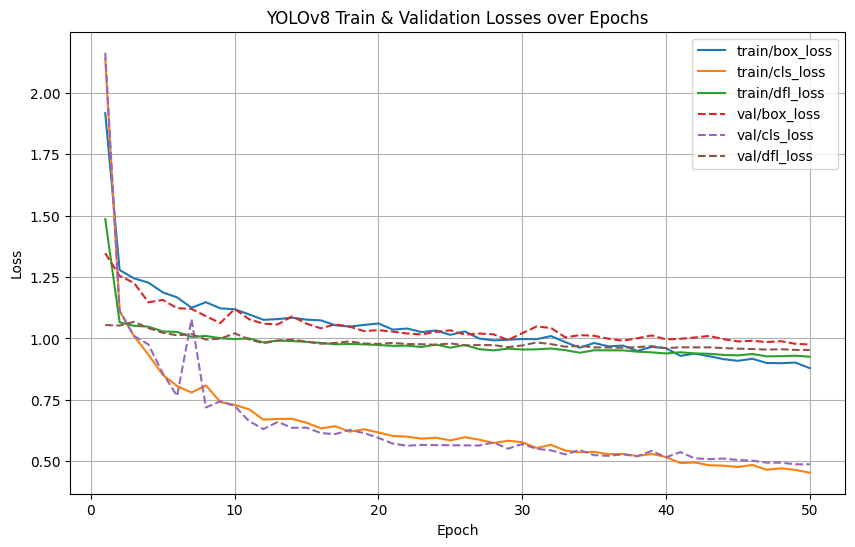

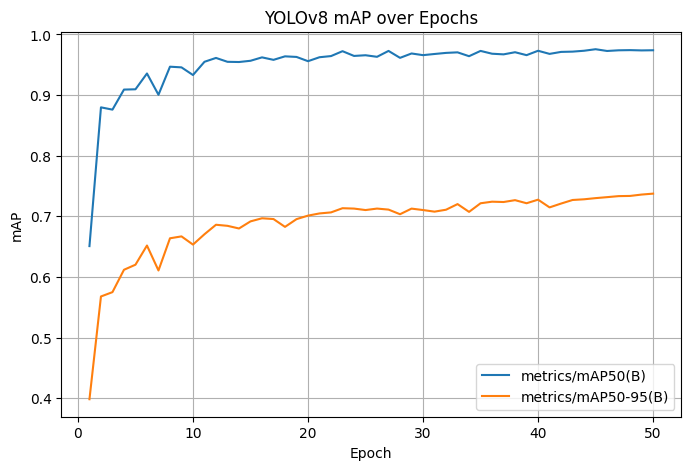

In [16]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

def find_latest_run(base_dir='runs/detect', prefix='yolov8n_custom_neck_vehicle_detection'):
    """
    Find the latest run folder under base_dir whose name starts with prefix.
    Returns the path to that folder, or None if not found.
    """
    pattern = os.path.join(base_dir, prefix + '*')
    runs = glob.glob(pattern)
    if not runs:
        return None
    # Sort by modification time
    runs_sorted = sorted(runs, key=lambda x: os.path.getmtime(x))
    return runs_sorted[-1]

def load_results_csv(run_folder):
    """
    Given the run folder path, load the results.csv into a cleaned DataFrame.
    """
    csv_path = os.path.join(run_folder, 'results.csv')
    if not os.path.isfile(csv_path):
        raise FileNotFoundError(f"No results.csv found in {run_folder}")
    df = pd.read_csv(csv_path)
    # Strip whitespace around column names
    df.columns = df.columns.str.strip()
    return df

def plot_losses(df, save_fig: bool = False, out_path='loss_plot.png'):
    """
    Plot box_loss, cls_loss, dfl_loss over epochs.
    Checks for both train/ and val/ columns.
    """
    epoch_col = 'epoch'
    if epoch_col not in df.columns:
        raise KeyError(f"Column '{epoch_col}' not found in DataFrame. Available columns: {df.columns.tolist()}")

    # Prepare possible keys
    metrics = ['box_loss', 'cls_loss', 'dfl_loss']
    # Determine available train/ and val/ columns
    train_cols = {m: f"train/{m}" for m in metrics if f"train/{m}" in df.columns}
    val_cols   = {m: f"val/{m}"   for m in metrics if f"val/{m}"   in df.columns}

    if not train_cols and not val_cols:
        raise KeyError(f"No train/ or val/ loss columns found among: {metrics}. Available columns: {df.columns.tolist()}")

    plt.figure(figsize=(10, 6))
    # Plot train losses
    for m, col in train_cols.items():
        plt.plot(df[epoch_col], df[col], label=f"train/{m}")
    # Plot val losses (dashed or different style)
    for m, col in val_cols.items():
        plt.plot(df[epoch_col], df[col], '--', label=f"val/{m}")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('YOLOv8 Train & Validation Losses over Epochs')
    plt.legend()
    plt.grid(True)
    if save_fig:
        plt.savefig(out_path, dpi=200)
        print(f"Saved loss plot to {out_path}")
    plt.show()

def plot_map(df, save_fig: bool = False, out_path='map_plot.png'):
    """
    Plot mAP metrics over epochs, if present.
    Typical columns: 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)'.
    """
    epoch_col = 'epoch'
    if epoch_col not in df.columns:
        print(f"Column '{epoch_col}' not found; skipping mAP plot. Available columns: {df.columns.tolist()}")
        return

    # Find possible mAP columns
    map_cols = [col for col in df.columns if 'mAP50' in col]
    if not map_cols:
        print("No mAP columns found in results.csv. Available columns:", df.columns.tolist())
        return

    plt.figure(figsize=(8, 5))
    for col in map_cols:
        # Some columns might be all NaN at early epochs; we still attempt to plot
        plt.plot(df[epoch_col], df[col], label=col)
    plt.xlabel('Epoch')
    plt.ylabel('mAP')
    plt.title('YOLOv8 mAP over Epochs')
    plt.legend()
    plt.grid(True)
    if save_fig:
        plt.savefig(out_path, dpi=200)
        print(f"Saved mAP plot to {out_path}")
    plt.show()

def main(run_folder=None):
    # 1. Determine run folder
    if run_folder is None:
        latest = find_latest_run()
        if latest is None:
            print("No run folder found matching the prefix. Please check the directory or specify run_folder manually.")
            return
        run_folder = latest
    print(f"Using run folder: {run_folder}")

    # 2. Load results.csv
    try:
        df = load_results_csv(run_folder)
    except Exception as e:
        print("Error loading results.csv:", e)
        return

    # 3. Inspect columns
    print("Columns in results.csv:", df.columns.tolist())

    # 4. Plot losses
    try:
        plot_losses(df, save_fig=False)
    except KeyError as e:
        print("Could not plot train/val losses:", e)

    # 5. Plot mAP
    plot_map(df, save_fig=False)

# If running as script in notebook or file:
if __name__ == '__main__':
    # Optionally, hardcode your run folder here:
    # run_folder = r"runs/detect/yolov8n_custom_neck_vehicle_detection2"
    # main(run_folder)
    main()


Loading model from: runs/detect/yolov8n_custom_neck_vehicle_detection/weights/best.pt
Running prediction on: C:/Users/avyaa/OneDrive/Desktop/Pythonfiles/.venv/Scripts/traffic_wala_dataset/valid/images/12_mp4-24_jpg.rf.b5c9acb867e41055973828d5c43ed57e.jpg

image 1/1 C:\Users\avyaa\OneDrive\Desktop\Pythonfiles\.venv\Scripts\traffic_wala_dataset\valid\images\12_mp4-24_jpg.rf.b5c9acb867e41055973828d5c43ed57e.jpg: 640x640 5 Vehicles, 22.5ms
Speed: 7.5ms preprocess, 22.5ms inference, 37.3ms postprocess per image at shape (1, 3, 640, 640)
Found 5 vehicles in the image.


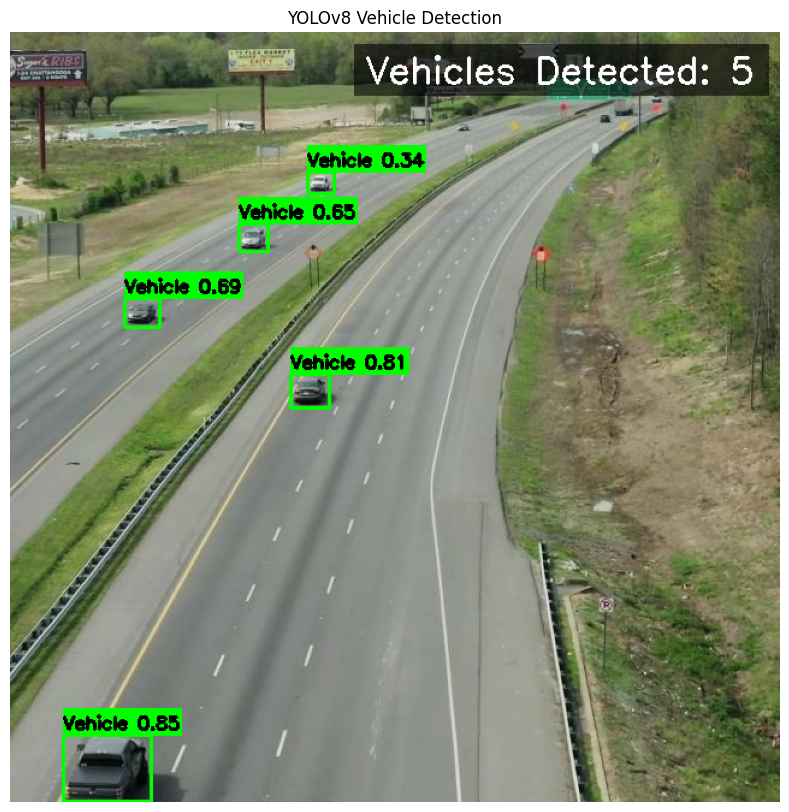

In [17]:
import cv2
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt

def predict_and_display(model_path: str, image_path: str, confidence_threshold: float = 0.5):
    """
    Loads a trained YOLOv8 model, performs prediction on a single image,
    and displays the image with bounding boxes and a detection count.

    Args:
        model_path (str): Path to the trained YOLOv8 model (.pt file).
        image_path (str): Path to the image file for prediction.
        confidence_threshold (float): Minimum confidence score for a detection to be considered.
                                      Defaults to 0.5.
    """
    # 1. Load the trained YOLO model
    print(f"Loading model from: {model_path}")
    try:
        model = YOLO(model_path)
    except Exception as e:
        print(f"Error loading model: {e}")
        return

    # 2. Perform prediction on the image
    print(f"Running prediction on: {image_path}")
    # The `predict` method returns a list of Results objects
    results = model.predict(image_path, conf=confidence_threshold)

    # 3. Load the image with OpenCV for drawing
    # We do this *after* prediction to get a clean image to draw on.
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read image at {image_path}")
        return

    # The result for the first (and only) image
    result = results[0]
    
    # 4. Count the number of detected bounding boxes
    detection_count = len(result.boxes)
    print(f"Found {detection_count} vehicles in the image.")

    # 5. Draw bounding boxes and labels on the image
    for box in result.boxes:
        # Get coordinates
        x1, y1, x2, y2 = [int(i) for i in box.xyxy[0]]
        
        # Get confidence and class
        confidence = box.conf[0]
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        
        # Define color and label text
        color = (0, 255, 0) # Green for the box
        label = f"{class_name} {confidence:.2f}"
        
        # Draw the rectangle
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        
        # Draw the label background and text
        (label_width, label_height), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
        cv2.rectangle(img, (x1, y1 - label_height - 10), (x1 + label_width, y1), color, -1)
        cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

    # 6. Add the total detection count to the top-right corner
    count_text = f"Vehicles Detected: {detection_count}"
    text_size, _ = cv2.getTextSize(count_text, cv2.FONT_HERSHEY_SIMPLEX, 1, 2)
    text_x = img.shape[1] - text_size[0] - 20  # 20 pixels padding from the right edge
    text_y = text_size[1] + 20                # 20 pixels padding from the top edge
    
    # Add a semi-transparent background for the text
    overlay = img.copy()
    cv2.rectangle(overlay, (text_x - 10, text_y - text_size[1] - 10), (text_x + text_size[0] + 10, text_y + 10), (0, 0, 0), -1)
    alpha = 0.6
    img = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)
    
    # Put the text on the image
    cv2.putText(img, count_text, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    # 7. Display the final image
    # Convert BGR (OpenCV's default) to RGB for Matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(15, 10))
    plt.imshow(img_rgb)
    plt.title("YOLOv8 Vehicle Detection")
    plt.axis('off') # Hide axes
    plt.show()


# --- MAIN EXECUTION ---
if __name__ == '__main__':
    # --- IMPORTANT: UPDATE THESE PATHS ---
    
    # Path to the best model weights you got from training
    MODEL_PATH = 'runs/detect/yolov8n_custom_neck_vehicle_detection/weights/best.pt'
    
    # Path to the image you want to test the model on
    # Replace this with the actual path to your test image
    IMAGE_PATH = 'C:/Users/avyaa/OneDrive/Desktop/Pythonfiles/.venv/Scripts/traffic_wala_dataset/valid/images/12_mp4-24_jpg.rf.b5c9acb867e41055973828d5c43ed57e.jpg' 
    
    # Example:
    # IMAGE_PATH = 'C:/Users/avyaa/Downloads/test_traffic_scene.jpg'
    
    # Call the function to see the results
    predict_and_display(model_path=MODEL_PATH, image_path=IMAGE_PATH, confidence_threshold=0.2)

In [4]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

def predict_and_display_inline(model_path: str, image_path: str, confidence_threshold: float = 0.5):
    """
    Loads a trained YOLOv8 model, performs prediction, and displays annotated image inline.
    """
    # 1. Load model
    model = YOLO(model_path)

    # 2. Predict
    results = model.predict(image_path, conf=confidence_threshold)

    # 3. Read image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read image at {image_path}")
        return

    # 4. Draw detections
    result = results[0]
    for box in result.boxes:
        x1, y1, x2, y2 = [int(i) for i in box.xyxy[0]]
        confidence = float(box.conf[0])
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        color = (0, 255, 0)
        label = f"{class_name} {confidence:.2f}"
        # Draw box
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        # Draw label background
        (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
        top_left = (x1, max(0, y1 - h - 10))
        bottom_right = (x1 + w, y1)
        cv2.rectangle(img, top_left, bottom_right, color, -1)
        cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

    # 5. Overlay total count
    detection_count = len(result.boxes)
    count_text = f"Vehicles Detected: {detection_count}"
    (tw, th), _ = cv2.getTextSize(count_text, cv2.FONT_HERSHEY_SIMPLEX, 1, 2)
    text_x = img.shape[1] - tw - 20
    text_y = th + 20
    overlay = img.copy()
    rect_tl = (text_x - 10, max(0, text_y - th - 10))
    rect_br = (text_x + tw + 10, text_y + 10)
    cv2.rectangle(overlay, rect_tl, rect_br, (0, 0, 0), -1)
    alpha = 0.6
    img = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)
    cv2.putText(img, count_text, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    # 6. Convert BGR to RGB and display inline
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title("YOLOv8 Vehicle Detection")
    plt.show()



image 1/1 C:\Users\avyaa\OneDrive\Desktop\Pythonfiles\.venv\Scripts\traffic_wala_dataset\valid\images\10_mp4-13_jpg.rf.aff71e875ee297d3086b715b7d6aaf26.jpg: 640x640 25 Vehicles, 21.3ms
Speed: 5.8ms preprocess, 21.3ms inference, 7.9ms postprocess per image at shape (1, 3, 640, 640)


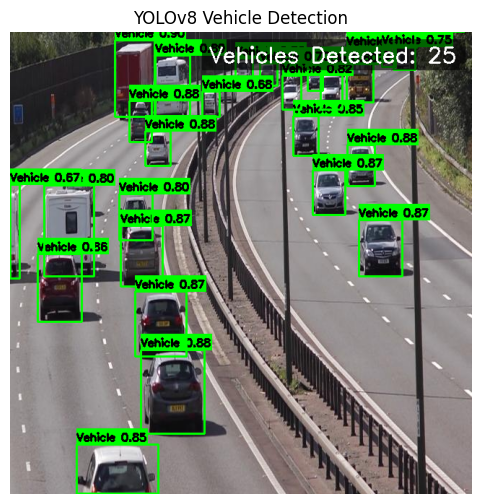

In [5]:
%matplotlib inline
predict_and_display_inline(
    model_path='runs/detect/yolov8n_custom_neck_vehicle_detection/weights/best.pt',
    image_path='C:/Users/avyaa/OneDrive/Desktop/Pythonfiles/.venv/Scripts/traffic_wala_dataset/valid/images/10_mp4-13_jpg.rf.aff71e875ee297d3086b715b7d6aaf26.jpg',
    confidence_threshold=0.5
)

In [18]:
import cv2
from ultralytics import YOLO

# Load the model
model = YOLO(MODEL_PATH)

# Path to your video
video_path = 'C:/Users/avyaa/OneDrive/Desktop/Pythonfiles/.venv/Scripts/traffic.mp4'
output_path = 'test_output.mp4'

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print(f"Error: Could not open video file {video_path}")
    exit()

# Get video properties (width, height, fps)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# Define the codec and create VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec for .mp4
out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

print("Processing video... This may take a moment.")

# Choose font for overlay
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 1
color = (0, 255, 0)  # green text
thickness = 2
line_type = cv2.LINE_AA

while True:
    ret, frame = cap.read()
    if not ret:
        break 

    # Inference
    results = model(frame)  
    # Draw the usual annotations (boxes, labels) using Ultralytics plot()
    annotated_frame = results[0].plot() 


    num_boxes = len(results[0].boxes)  

   
    text = f"Detections: {num_boxes}"
   
    org = (10, 30)  # (x, y) in pixels
    cv2.putText(annotated_frame, text, org, font, font_scale, color, thickness, line_type)



    # Write the annotated frame (with overlay) to output
    out.write(annotated_frame)

cap.release()
out.release()

print("Processing complete!")
print(f"Custom video saved to: {output_path}")


Processing video... This may take a moment.

0: 384x640 12 Vehicles, 71.1ms
Speed: 4.9ms preprocess, 71.1ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 Vehicles, 11.8ms
Speed: 3.4ms preprocess, 11.8ms inference, 3.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 Vehicles, 10.7ms
Speed: 3.0ms preprocess, 10.7ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 Vehicles, 12.4ms
Speed: 2.5ms preprocess, 12.4ms inference, 2.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 Vehicles, 11.0ms
Speed: 2.9ms preprocess, 11.0ms inference, 2.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 Vehicles, 10.8ms
Speed: 2.9ms preprocess, 10.8ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 Vehicles, 12.8ms
Speed: 2.7ms preprocess, 12.8ms inference, 3.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 12 Vehicles, 100.9ms
Speed: 3.2ms preproc

In [19]:
import cv2
import numpy as np
from ultralytics import YOLO
from tqdm import tqdm # For a progress bar

# --- 1. CONFIGURATION ---

# Model and Video Paths
MODEL_PATH = MODEL_PATH  
VIDEO_SOURCE_PATH = 'C:/Users/avyaa/OneDrive/Desktop/Pythonfiles/.venv/Scripts/sample_video.mp4'
VIDEO_OUTPUT_PATH = 'traffic_density_analysis.mp4' # Changed to .mp4 for better compatibility

VERTICES_LEFT_LANE = np.array([(465, 350), (609, 350), (510, 630), (2, 630)], dtype=np.int32)
VERTICES_RIGHT_LANE = np.array([(678, 350), (815, 350), (1203, 630), (743, 630)], dtype=np.int32)
DETECTION_Y_START = 325
DETECTION_Y_END = 635

# Traffic Logic
HEAVY_TRAFFIC_THRESHOLD = 10 

# Annotation Settings
FONT = cv2.FONT_HERSHEY_SIMPLEX
FONT_SCALE = 0.9
FONT_THICKNESS = 2
TEXT_COLOR = (255, 255, 255) # White
BACKGROUND_COLOR = (0, 0, 255) # Red

# --- 2. INITIALIZATION ---

print("Loading YOLO model...")
model = YOLO(MODEL_PATH)

print(f"Opening video source: {VIDEO_SOURCE_PATH}")
cap = cv2.VideoCapture(VIDEO_SOURCE_PATH)
if not cap.isOpened():
    print(f"Error: Could not open video file at {VIDEO_SOURCE_PATH}")
    exit()

# Get video properties for the output file
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Define the codec and create VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(VIDEO_OUTPUT_PATH, fourcc, fps, (frame_width, frame_height))

# --- 3. VIDEO PROCESSING LOOP ---

for _ in tqdm(range(total_frames), desc="Analyzing Video Frames"):
    ret, frame = cap.read()
    if not ret:
        break

    detection_frame = frame.copy()
    detection_frame[:DETECTION_Y_START, :] = 0
    detection_frame[DETECTION_Y_END:, :] = 0

    results = model.predict(detection_frame, imgsz=640, conf=0.4, verbose=False)
    processed_frame = results[0].plot(line_width=1)
    
    processed_frame[:DETECTION_Y_START, :] = frame[:DETECTION_Y_START, :].copy()
    processed_frame[DETECTION_Y_END:, :] = frame[DETECTION_Y_END:, :].copy()

    vehicles_in_left_lane = 0
    vehicles_in_right_lane = 0
    
    # --- THIS IS THE FIX ---
    # Convert the PyTorch tensor to a NumPy array for use with OpenCV
    bounding_boxes = results[0].boxes.xyxy.cpu().numpy()

    for box in bounding_boxes:
        center_x = (box[0] + box[2]) / 2
        center_y = (box[1] + box[3]) / 2
        
        # Now this check will work correctly because the coordinates are NumPy/Python numbers
        if cv2.pointPolygonTest(VERTICES_LEFT_LANE, (center_x, center_y), False) >= 0:
            vehicles_in_left_lane += 1
        elif cv2.pointPolygonTest(VERTICES_RIGHT_LANE, (center_x, center_y), False) >= 0:
            vehicles_in_right_lane += 1

    cv2.polylines(processed_frame, [VERTICES_LEFT_LANE], isClosed=True, color=(0, 255, 0), thickness=2)
    cv2.polylines(processed_frame, [VERTICES_RIGHT_LANE], isClosed=True, color=(0, 255, 0), thickness=2)

    intensity_left = "Heavy" if vehicles_in_left_lane > HEAVY_TRAFFIC_THRESHOLD else "Smooth"
    intensity_right = "Heavy" if vehicles_in_right_lane > HEAVY_TRAFFIC_THRESHOLD else "Smooth"
    
    left_lane_text = f'Left Lane: {vehicles_in_left_lane} ({intensity_left})'
    right_lane_text = f'Right Lane: {vehicles_in_right_lane} ({intensity_right})'

    def draw_text_with_bg(img, text, position):
        (text_width, text_height), _ = cv2.getTextSize(text, FONT, FONT_SCALE, FONT_THICKNESS)
        bg_rect_pos = (position[0], position[1] - text_height - 5)
        bg_rect_end = (position[0] + text_width + 10, position[1] + 5) # Added a small padding
        cv2.rectangle(img, bg_rect_pos, bg_rect_end, BACKGROUND_COLOR, -1)
        cv2.putText(img, text, position, FONT, FONT_SCALE, TEXT_COLOR, FONT_THICKNESS, cv2.LINE_AA)

    draw_text_with_bg(processed_frame, left_lane_text, (30, 50))
    draw_text_with_bg(processed_frame, right_lane_text, (frame_width - 450, 50))
    
    out.write(processed_frame)

# --- 4. CLEANUP ---
cap.release()
out.release()

print("-" * 50)
print("✅ Processing complete.")
print(f"📹 Output video saved to: {VIDEO_OUTPUT_PATH}")
print("-" * 50)

Loading YOLO model...
Opening video source: C:/Users/avyaa/OneDrive/Desktop/Pythonfiles/.venv/Scripts/sample_video.mp4


Analyzing Video Frames: 100%|██████████| 601/601 [00:26<00:00, 22.30it/s]


--------------------------------------------------
✅ Processing complete.
📹 Output video saved to: traffic_density_analysis.mp4
--------------------------------------------------


In [14]:
pip install filterpy

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110628 sha256=271716532cb395b6765f4ae65c6080d5b13e75ba6f272ce978fd6ea2d722bb45
  Stored in directory: c:\users\avyaa\appdata\local\pip\cache\wheels\12\dc\3c\e12983eac132d00f82a20c6cbe7b42ce6e96190ef8fa2d15e1
Successfully built filterpy
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
from tqdm import tqdm
from collections import defaultdict

# --- 1. CONFIGURATION ---

# Model and Video Paths
MODEL_PATH = MODEL_PATH # Or your custom model path
VIDEO_SOURCE_PATH = 'C:/Users/avyaa/OneDrive/Desktop/Pythonfiles/.venv/Scripts/sample_video.mp4'
VIDEO_OUTPUT_PATH = 'traffic_speed_analysis.mp4'

# --- CALIBRATION ---
REAL_WORLD_LANE_LENGTH_METERS = 51 # The calibrated real-world length of the ROI

# ROI and Lane Definitions
VERTICES_LEFT_LANE = np.array([(465, 350), (609, 350), (510, 630), (2, 630)], dtype=np.int32)
VERTICES_RIGHT_LANE = np.array([(678, 350), (815, 350), (1203, 630), (743, 630)], dtype=np.int32)

# Detection and Tracking Settings
# It's often better to keep this lower for tracking to maintain object IDs
CONFIDENCE_THRESHOLD = 0.4 

# Annotation Settings
FONT = cv2.FONT_HERSHEY_SIMPLEX
FONT_SCALE = 0.7
FONT_THICKNESS = 2
TEXT_COLOR = (255, 255, 255) # White

# --- 2. INITIALIZATION ---

print("Loading YOLO model...")
model = YOLO(MODEL_PATH)

print(f"Opening video source: {VIDEO_SOURCE_PATH}")
cap = cv2.VideoCapture(VIDEO_SOURCE_PATH)
if not cap.isOpened():
    print(f"Error: Could not open video file at {VIDEO_SOURCE_PATH}")
    exit()

# Get video properties
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
time_per_frame = 1.0 / fps

# Define the codec and create VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(VIDEO_OUTPUT_PATH, fourcc, fps, (frame_width, frame_height))

# --- Perspective Transformation Setup ---
target_width = 100 
target_height = int(REAL_WORLD_LANE_LENGTH_METERS * 10) 

TARGET_RECT = np.array([
    [0, 0], [target_width - 1, 0],
    [target_width - 1, target_height - 1], [0, target_height - 1]
], dtype=np.float32)

M_left = cv2.getPerspectiveTransform(VERTICES_LEFT_LANE.astype(np.float32), TARGET_RECT)
M_right = cv2.getPerspectiveTransform(VERTICES_RIGHT_LANE.astype(np.float32), TARGET_RECT)

# --- Tracking Data Storage ---
track_history = defaultdict(list)
speed_history = defaultdict(list)

# --- 3. VIDEO PROCESSING LOOP ---
frame_number = 0
for _ in tqdm(range(total_frames), desc="Analyzing Video Frames"):
    ret, frame = cap.read()
    if not ret:
        break
    
    frame_number += 1

    # --- A. Run YOLO Tracking ---
    # <-- THE FIX IS HERE: `conf` argument is added
    results = model.track(frame, persist=True, verbose=False, conf=CONFIDENCE_THRESHOLD)

    # Get bounding boxes and track IDs
    try:
        boxes = results[0].boxes.xywh.cpu().numpy()
        track_ids = results[0].boxes.id.int().cpu().numpy()
    except AttributeError:
        out.write(frame)
        continue
    
    annotated_frame = results[0].plot(line_width=1)

    # --- B. Process Each Tracked Vehicle ---
    for box, track_id in zip(boxes, track_ids):
        x, y, w, h = box
        
        bottom_center_pixel = np.array([[[x, y + h]]], dtype=np.float32)
        
        in_left_lane = cv2.pointPolygonTest(VERTICES_LEFT_LANE, (bottom_center_pixel[0][0][0], bottom_center_pixel[0][0][1]), False) >= 0
        in_right_lane = cv2.pointPolygonTest(VERTICES_RIGHT_LANE, (bottom_center_pixel[0][0][0], bottom_center_pixel[0][0][1]), False) >= 0

        if in_left_lane or in_right_lane:
            M = M_left if in_left_lane else M_right
            real_world_point = cv2.perspectiveTransform(bottom_center_pixel, M)[0][0]
            
            track_history[track_id].append((frame_number, real_world_point))

            # --- C. Calculate Speed ---
            if len(track_history[track_id]) > 1:
                prev_frame_num, prev_point = track_history[track_id][-2]
                current_frame_num, current_point = track_history[track_id][-1]
                
                distance_meters = abs(current_point[1] - prev_point[1]) / (target_height / REAL_WORLD_LANE_LENGTH_METERS)
                time_elapsed = (current_frame_num - prev_frame_num) * time_per_frame
                
                if time_elapsed > 0:
                    speed_ms = distance_meters / time_elapsed
                    current_speed_kph = speed_ms * 3.6
                    
                    speed_history[track_id].append(current_speed_kph)
                    
                    if len(speed_history[track_id]) > 5:
                        speed_history[track_id].pop(0)
                    
                    smoothed_speed_kph = np.mean(speed_history[track_id])

                    # --- D. Annotate Frame ---
                    text = f"ID: {track_id} | {smoothed_speed_kph:.1f} km/h"
                    text_pos = (int(x - w / 2), int(y - h / 2) - 10)
                    cv2.putText(annotated_frame, text, text_pos, FONT, FONT_SCALE, (0, 0, 255), FONT_THICKNESS, cv2.LINE_AA)

    # Draw the ROI polygons
    cv2.polylines(annotated_frame, [VERTICES_LEFT_LANE], isClosed=True, color=(0, 255, 0), thickness=2)
    cv2.polylines(annotated_frame, [VERTICES_RIGHT_LANE], isClosed=True, color=(0, 255, 0), thickness=2)

    out.write(annotated_frame)

# --- 4. CLEANUP ---
cap.release()
out.release()

print("-" * 50)
print("Processing complete.")
print(f"Output video with speed estimation saved to: {VIDEO_OUTPUT_PATH}")
print("-" * 50)